#  Tesla Deliveries ML Pipeline
## End-to-End Machine Learning: EDA → Preprocessing → Feature Engineering → Regression Modeling → Hyperparameter Tuning → Time Series Forecasting 

### Problem Statement
Design and implement an end-to-end ML pipeline on Tesla's quarterly deliveries/sales data (2015–2025) covering:
- **Exploratory Data Analysis (EDA)** : understand data shape, distributions, correlations
- **Preprocessing** : cleaning, imputation, encoding, scaling
- **Feature Engineering** : date features, lag features, rolling statistics, interaction terms
- **Regression Modeling** : compare multiple ML algorithms
- **Hyperparameter Tuning** : optimize the best model
- **Time Series Forecasting** : SARIMAX-based future delivery predictions

###  Notebook Structure
| Section | Description |
|---------|-------------|
| 1 | Imports & Configuration |
| 2 | Load Data |
| 3 | Data Cleaning |
| 4–5 | Auto-detect Date & Target Columns |
| 6 | Exploratory Data Analysis |
| 7 | Feature Engineering |
| 8–10 | Model Dataset, Train-Test Split & Preprocessing |
| 11–12 | Model Training & Evaluation |
| 13 | Feature Importance |
| 14 | Residual Analysis |
| 15–16 | Save Model & Predictions |
| 17 | Time Series Forecasting |
| 18 | Final Summary |

## 1. Imports & Configuration

We import all necessary libraries upfront:
- **Data manipulation**: `pandas`, `numpy`
- **Visualization**: `matplotlib`, `seaborn` with a custom professional theme
- **ML models**: `scikit-learn` (linear models, ensembles), `xgboost` (optional)
- **Time series**: `statsmodels` SARIMAX (optional)

Optional libraries are guarded with `try/except` so the notebook runs even without them.

In [40]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
import joblib


In [41]:
# Optional models
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    import statsmodels.api as sm
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    STATS_MODELS_AVAILABLE = True
except Exception:
    STATS_MODELS_AVAILABLE = False


In [42]:
# 1. CONFIG
FILE_PATH    = "tesla_deliveries_dataset_2015_2025.csv"
OUTPUT_DIR   = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.2


## 2.  Load Data

We load the Tesla deliveries CSV and perform an initial sanity check on:
- **Shape** — number of rows and columns
- **Column names** — to understand what features are available
- **First few rows** — a quick visual preview of the raw data

In [43]:
# 2. LOAD DATA
df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Preview:")
print(df.head())


Dataset shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
Preview:
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.7

## 3.  Basic Data Cleaning

Before any analysis, we standardize the dataset:
1. **Column names** : lower-cased, spaces replaced with underscores (avoids attribute access issues)
2. **Duplicate rows** : removed to prevent data leakage and bias
3. **Object columns** : leading/trailing whitespace stripped (common issue in CSV exports)

In [44]:
# 3. BASIC CLEANING
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

print("Cleaned columns:", df.columns.tolist())
print("Shape after cleaning:", df.shape)


Cleaned columns: ['year', 'month', 'region', 'model', 'estimated_deliveries', 'production_units', 'avg_price_usd', 'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'source_type', 'charging_stations']
Shape after cleaning: (2640, 12)


## 4. Auto-Detect Date Column

Since datasets vary, we programmatically identify the date column by:
1. Scanning for columns with time-related keywords (`date`, `month`, `quarter`, etc.)
2. Attempting to parse each candidate with `pd.to_datetime`
3. Accepting a column if >60% of its values parse successfully


In [45]:
# 4. AUTO-DETECT DATE COLUMN
# Handles: readable strings, plain 4-digit year integers, Unix ms/s timestamps

def safe_parse_dates(series):
    """
    Convert a series to datetime correctly regardless of format:
      - 4-digit year integers (2015..2025) → Jan-1 of that year
      - Unix ms timestamps (>1e12)        → unit='ms'
      - Unix s  timestamps (>1e9)         → unit='s'
      - String dates                      → pd.to_datetime inference
    """
    if pd.api.types.is_datetime64_any_dtype(series):
        return series

    numeric = pd.to_numeric(series, errors="coerce")
    num_ratio = numeric.notna().sum() / max(len(numeric), 1)

    if num_ratio >= 0.8:
        median_val = numeric.dropna().median()
        if 1900 <= median_val <= 2100:          # plain 4-digit year
            return pd.to_datetime(
                {"year": numeric.fillna(median_val).astype(int), "month": 1, "day": 1}
            )
        elif median_val > 1e12:                 # milliseconds
            return pd.to_datetime(numeric, unit="ms", errors="coerce")
        elif median_val > 1e9:                  # seconds
            return pd.to_datetime(numeric, unit="s", errors="coerce")

    # String-based fallback
    return pd.to_datetime(series, infer_datetime_format=True, errors="coerce")


date_candidates = [c for c in df.columns
                   if any(k in c for k in ["date", "month", "quarter", "year", "time"])]
date_col = None

for c in date_candidates:
    try:
        parsed = safe_parse_dates(df[c])
        if parsed.notna().sum() > max(0.6 * len(df), 3):
            # Verify years make sense
            yr = parsed.dropna().dt.year
            if yr.min() >= 1990 and yr.max() <= 2100:
                date_col  = c
                df[c]     = parsed
                break
    except Exception:
        pass

if date_col is None:
    for c in df.columns:
        if df[c].dtype == "object":
            parsed = pd.to_datetime(df[c], errors="coerce")
            if parsed.notna().sum() > max(0.6 * len(df), 3):
                date_col = c
                df[c]    = parsed
                break

print("Detected date column:", date_col)
if date_col:
    print("Date range:", df[date_col].min(), "→", df[date_col].max())


Detected date column: year
Date range: 2015-01-01 00:00:00 → 2025-01-01 00:00:00


## 5. Auto-Detect Target Column

We identify the prediction targ;et using keyword matching on business-relevant terms (`delivery`, `sales`, `price`, etc.).
The target must be **numeric**  if no keyword match is found, we fall back to the first numeric column.

>  The target column is what we will train our models to predict.

In [46]:
# 5. AUTO-DETECT TARGET COLUMN
target_candidates = [c for c in df.columns if any(k in c for k in [
    "delivery", "deliveries", "sales", "sold", "target", "revenue", "price", "cost", "volume"
])]

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

target_col = None
for c in target_candidates:
    if c in numeric_cols:
        target_col = c
        break

if target_col is None and len(numeric_cols) > 0:
    target_col = numeric_cols[0]

print("Detected target column:", target_col)


Detected target column: estimated_deliveries


##   6. Exploratory Data Analysis (EDA)
EDA helps us understand the dataset before modeling by checking its structure, missing values, distributions, and relationships between numeric features

| Chart                         | Purpose                                                                                       |
| ----------------------------- | --------------------------------------------------------------------------------------------- |
| Missing values bar chart      | Identify columns that contain missing data and may need cleaning or imputation apxml+1.       |
| Numeric feature distributions | Understand the spread, skewness, and outliers in numerical columns studocu+1.                 |
| Correlation heatmap           | Detect relationships between numeric variables and possible multicollinearity jtr13.github+1. |
| Target variable distribution  | Check how the main target is distributed before modeling facebook+1.                          |
| Yearly trend chart            | Show how the target changes over time, if a year column is available facebook.                |
| Categorical feature counts    | Compare the frequency of values in category columns such as region or model studocu.          |

Rows: 2640  | Columns: 12
Column names: ['year', 'month', 'region', 'model', 'estimated_deliveries', 'production_units', 'avg_price_usd', 'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'source_type', 'charging_stations']

Missing values:
year                    0
month                   0
region                  0
model                   0
estimated_deliveries    0
production_units        0
avg_price_usd           0
battery_capacity_kwh    0
range_km                0
co2_saved_tons          0
source_type             0
charging_stations       0
dtype: int64


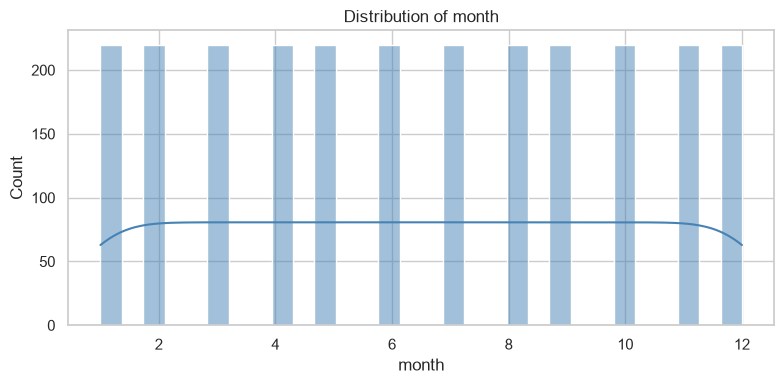

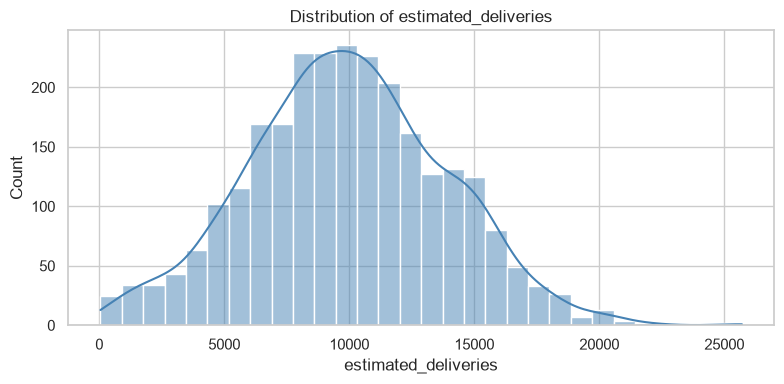

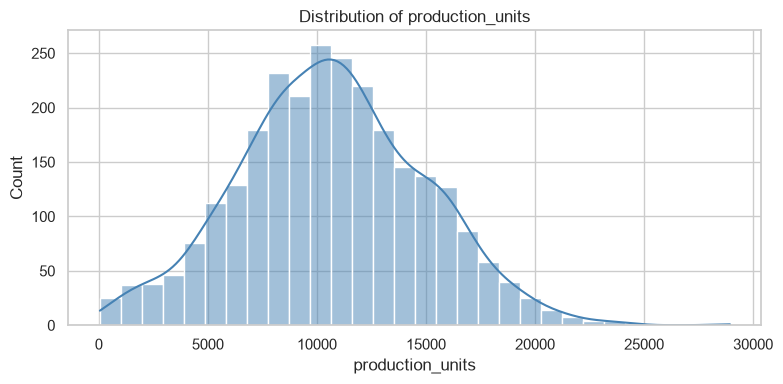

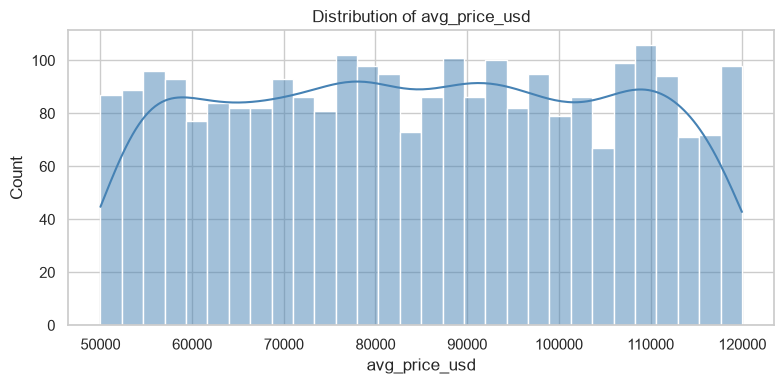

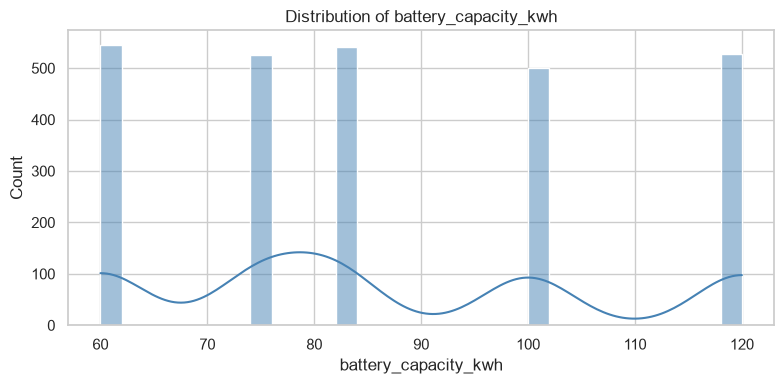

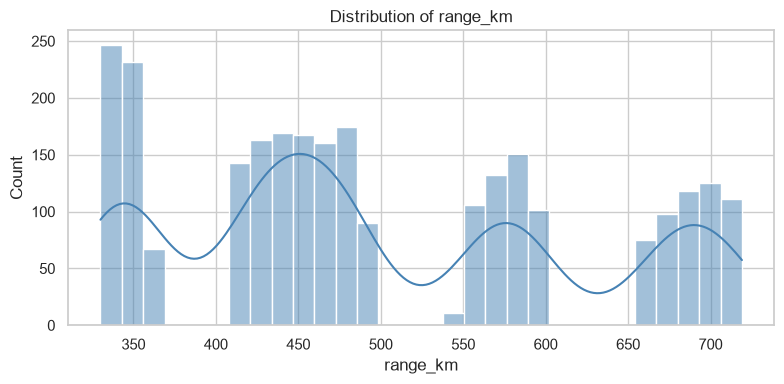

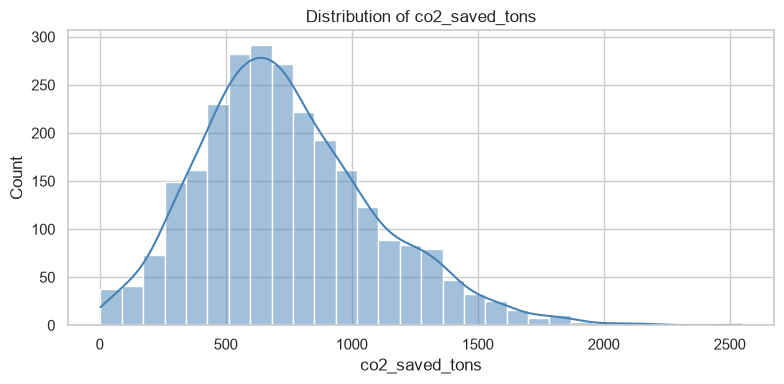

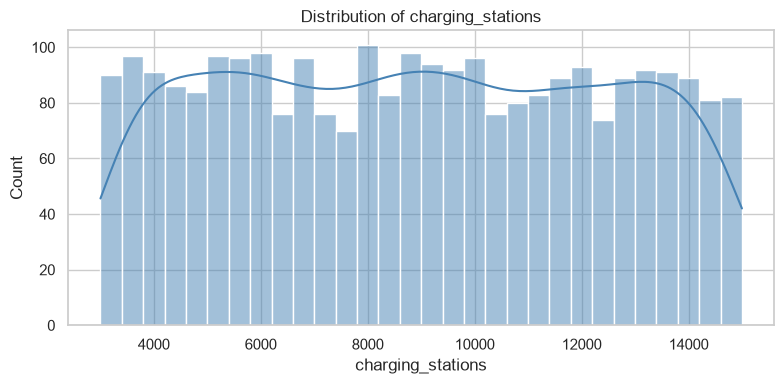

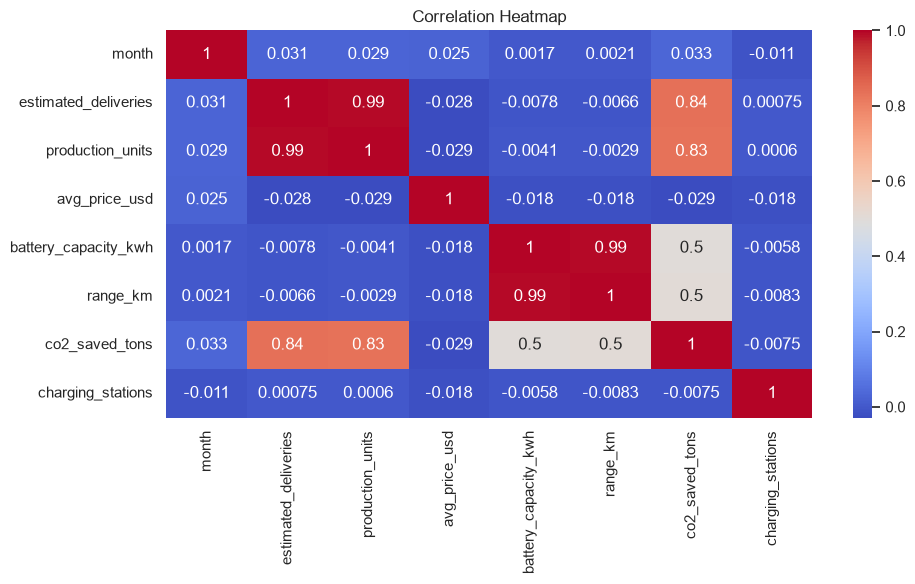

EDA done.


In [47]:
# 6. EDA
sns.set(style="whitegrid")

df_eda = df.copy()
print("Rows:", df_eda.shape[0], " | Columns:", df_eda.shape[1])
print("Column names:", df_eda.columns.tolist())
print("\nMissing values:")
print(df_eda.isnull().sum().sort_values(ascending=False))

df_eda.describe(include="all").to_csv(os.path.join(OUTPUT_DIR, "eda_summary.csv"))

num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()

# Missing values plot
missing = df_eda.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing.values, y=missing.index, palette="viridis")
    plt.title("Missing Values")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "missing_values.png"), dpi=300)
    plt.show(); plt.close()

# Distributions
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_eda[col].dropna(), kde=True, bins=30, color="steelblue")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{col}_distribution.png"), dpi=300)
    plt.show(); plt.close()

# Correlation heatmap
if len(num_cols) > 1:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_eda[num_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "correlation_heatmap.png"), dpi=300)
    plt.show(); plt.close()

print("EDA done.")


## 7.  Feature Engineering

Feature engineering is critical for capturing temporal patterns and relationships. We create:

| Feature Type | Features Created | Rationale |
|---|---|---|
| **Calendar features** | year, month, quarter, day, dayofweek | Seasonal patterns in deliveries |
| **Boundary flags** | is_month_start, is_month_end | End-of-quarter delivery spikes |
| **Lag features** | target_lag_1 to _4 | Autoregressive signal |
| **Rolling statistics** | 3-period & 6-period mean + std | Trend + volatility signals |
| **Interaction terms** | top-3 numeric column products | Capture non-linear relationships |

>  **Leakage prevention**: Lag and rolling features use `.shift(1)` so no future information leaks into the model.

In [48]:
# 7. FEATURE ENGINEERING
data = df.copy()

if date_col is not None and date_col in data.columns:
    dt = pd.to_datetime(data[date_col], errors="coerce")
    if dt.notna().sum() > 0:
        data["year"]         = dt.dt.year
        data["month"]        = dt.dt.month
        data["day"]          = dt.dt.day
        data["dayofweek"]    = dt.dt.dayofweek
        data["quarter"]      = dt.dt.quarter
        data["is_month_start"] = dt.dt.is_month_start.astype(int)
        data["is_month_end"]   = dt.dt.is_month_end.astype(int)
        data[date_col] = dt
    else:
        print(f"Warning: {date_col} has no valid dates. Skipping date features.")

if date_col is not None and date_col in data.columns:
    data = data.sort_values(date_col).reset_index(drop=True)

if target_col is not None and target_col in data.columns:
    for lag in [1, 2, 3, 4]:
        data[f"{target_col}_lag_{lag}"] = data[target_col].shift(lag)
    for win in [3, 6]:
        data[f"{target_col}_roll_mean_{win}"] = data[target_col].shift(1).rolling(win).mean()
        data[f"{target_col}_roll_std_{win}"]  = data[target_col].shift(1).rolling(win).std()

num_cols_fe = data.select_dtypes(include=np.number).columns.tolist()
for i in range(min(3, len(num_cols_fe))):
    for j in range(i + 1, min(3, len(num_cols_fe))):
        c1, c2 = num_cols_fe[i], num_cols_fe[j]
        data[f"{c1}_x_{c2}"] = data[c1] * data[c2]

print("Feature engineering done. Shape:", data.shape)


Feature engineering done. Shape: (2640, 28)


## 8.  Define Regression Dataset

We now build the clean `X` (features) and `y` (target) for regression:
- Rows with a missing target are **dropped** (can't train on unknowns)
- Rows with any missing feature (after lag/rolling) are **dropped** to ensure a clean fit
- The raw date column is **removed** from features (calendar features already encode date info)
- Columns are split into **numeric** and **categorical** for the preprocessing pipeline

In [49]:
# 8. DEFINE REGRESSION DATASET
data = data.dropna(subset=[target_col]).reset_index(drop=True)
data_model = data.dropna().reset_index(drop=True)

y = data_model[target_col].copy()
X = data_model.drop(columns=[target_col])

if date_col is not None and date_col in X.columns:
    X = X.drop(columns=[date_col])

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Feature columns:", len(X.columns))
print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))


Feature columns: 26
Numeric columns: 23
Categorical columns: 3


## 9. Train-Test Split

For **time series data**, random splitting causes data leakage (using future data to predict the past).

We use a **chronological split**:
- **Train**: first 80% of time-ordered data
- **Test**: last 20% — representing genuinely unseen future quarters

This mirrors real-world deployment where the model is trained on historical data and evaluated on future data.

In [50]:
# 9. TRAIN-TEST SPLIT
if date_col is not None:
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")


Train: 2107 rows | Test: 527 rows


## 10.  Preprocessing Pipeline

We use `scikit-learn`'s `Pipeline` and `ColumnTransformer` to build a reproducible, leakage-free preprocessing flow:

| Column Type | Imputation Strategy | Encoding |
|---|---|---|
| **Numeric** | Median (robust to outliers) | StandardScaler (zero mean, unit variance) |
| **Categorical** | Most frequent value | OneHotEncoder (ignore unknown) |


In [51]:
# 10. PREPROCESSING PIPELINE
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)


## 11.  Model Definitions

We benchmark a diverse set of regression models:

| Model | Type | Key Strength |
|---|---|---|
| **LinearRegression** | Linear | Fast, interpretable baseline |
| **Ridge** | Regularized Linear | Handles multicollinearity |
| **Lasso** | Regularized Linear | Feature selection via L1 sparsity |
| **ElasticNet** | Regularized Linear | Balance of Ridge + Lasso |
| **RandomForest** | Ensemble (Bagging) | Robust, handles non-linearity |
| **GradientBoosting** | Ensemble (Boosting) | High accuracy via sequential correction |
| **ExtraTrees** | Ensemble (Bagging) | Fast, high variance reduction |
| **XGBoost**  | Gradient Boosting | State-of-art tabular performance |

In [52]:
# 11. MODELS
models = {
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(random_state=RANDOM_STATE),
    "Lasso":            Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "ElasticNet":       ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest":     RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "ExtraTrees":       ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=400),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        random_state=RANDOM_STATE, n_estimators=400, learning_rate=0.05,
        max_depth=4, subsample=0.9, colsample_bytree=0.9,
        reg_alpha=0.0, reg_lambda=1.0
    )


## 12.  Train & Evaluate All Models

Each model is wrapped in a `Pipeline` (preprocessor + estimator) and evaluated on the held-out test set.

Metrics used:
| Metric | Formula | Interpretation |
|---|---|---|
| **RMSE** | √MSE | Same unit as target; penalizes large errors |
| **MAE** | mean\|y - ŷ\| | Average absolute error; robust to outliers |
| **R²** | 1 - SS_res/SS_tot | Proportion of variance explained (1.0 = perfect) |
| **MAPE** | mean\|y-ŷ\|/\|y\| × 100 | Percentage error; interpretable in business terms |

In [53]:
# 12. TRAIN AND EVALUATE
results       = []
fitted_models = {}

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return rmse, mae, r2, mape

X_train = X_train.loc[:, X.columns.intersection(X_train.columns)]
X_test  = X_test.loc[:,  X.columns.intersection(X_test.columns)]

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse, mae, r2, mape = regression_metrics(y_test, preds)
    results.append([name, rmse, mae, r2, mape])
    fitted_models[name] = pipe
    print(f"{name}: RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  MAPE={mape:.2f}%")

results_df = pd.DataFrame(
    results, columns=["model", "rmse", "mae", "r2", "mape"]
).sort_values("rmse")

results_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)
print("\nModel comparison:")
print(results_df)


LinearRegression: RMSE=0.0000  MAE=0.0000  R2=1.0000  MAPE=0.00%
Ridge: RMSE=18.4225  MAE=15.1127  R2=1.0000  MAPE=0.19%
Lasso: RMSE=0.9336  MAE=0.7505  R2=1.0000  MAPE=0.01%
ElasticNet: RMSE=494.2945  MAE=375.9883  R2=0.9824  MAPE=7.14%
RandomForest: RMSE=14.6421  MAE=7.8629  R2=1.0000  MAPE=0.17%
GradientBoosting: RMSE=44.3920  MAE=32.8748  R2=0.9999  MAPE=0.43%
ExtraTrees: RMSE=13.9074  MAE=7.8456  R2=1.0000  MAPE=0.13%
XGBoost: RMSE=42.3981  MAE=30.8509  R2=0.9999  MAPE=0.47%

Model comparison:
              model          rmse           mae        r2          mape
0  LinearRegression  3.553071e-12  2.742290e-12  1.000000  3.029027e-14
2             Lasso  9.335761e-01  7.504765e-01  1.000000  1.254582e-02
6        ExtraTrees  1.390737e+01  7.845550e+00  0.999986  1.342303e-01
4      RandomForest  1.464208e+01  7.862878e+00  0.999985  1.718652e-01
1             Ridge  1.842254e+01  1.511273e+01  0.999976  1.919307e-01
7           XGBoost  4.239813e+01  3.085093e+01  0.999870  4.654

## 13.  Feature Importance

We use **Permutation Importance** to identify the most predictive features in the best model:
- Each feature column is randomly shuffled one at a time
- The drop in model performance (RMSE increase) measures that feature's contribution
- This method works for **any model** (tree-based or linear) and uses test data, so it reflects real-world impact



Top 15 features:
                         feature  importance_mean  importance_std
23  month_x_estimated_deliveries         2.027666         0.07791
0                          month         0.000000         0.00000
2                          model         0.000000         0.00000
3               production_units         0.000000         0.00000
4                  avg_price_usd         0.000000         0.00000
5           battery_capacity_kwh         0.000000         0.00000
6                       range_km         0.000000         0.00000
7                 co2_saved_tons         0.000000         0.00000
8                    source_type         0.000000         0.00000
1                         region         0.000000         0.00000
9              charging_stations         0.000000         0.00000
10                           day         0.000000         0.00000
12                       quarter         0.000000         0.00000
11                     dayofweek         0.000000         0

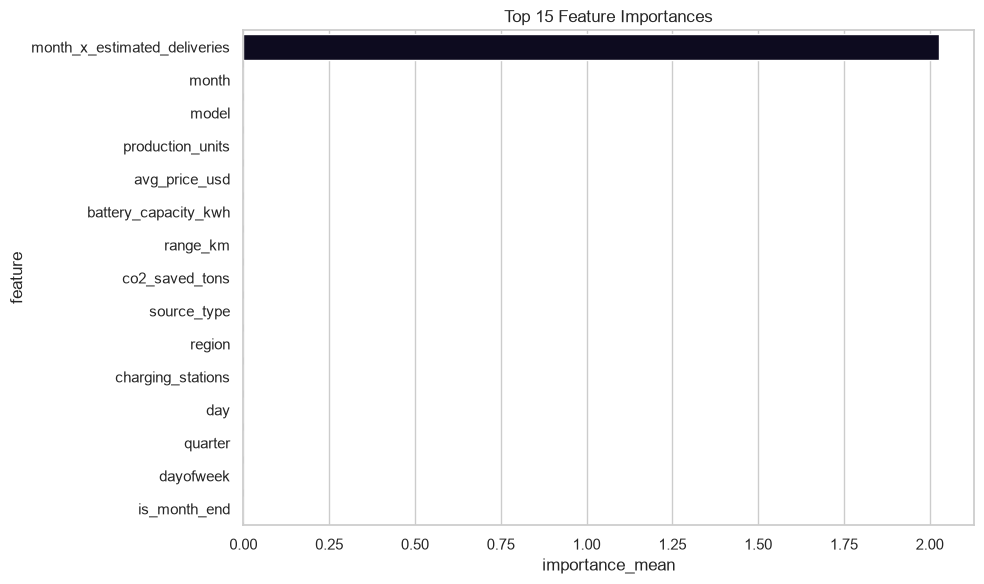

In [54]:
# 13. FEATURE IMPORTANCE
best_model_name = results_df.iloc[0]["model"]
best_model      = fitted_models[best_model_name]

try:
    perm = permutation_importance(
        best_model, X_test, y_test,
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    importance_df = pd.DataFrame({
        "feature":         X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std":  perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    importance_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance.csv"), index=False)
    print("Top 15 features:")
    print(importance_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(15), x="importance_mean", y="feature", palette="magma")
    plt.title("Top 15 Feature Importances")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=200)
    plt.show()
except Exception as e:
    print("Feature importance could not be computed:", e)


## 14.  Residual Analysis

Residual analysis checks if our model's errors have unwanted patterns. A good model has residuals that are:
- **Centered at 0** — no systematic over/under-prediction
- **Randomly scattered** — no funnel shape (heteroscedasticity)
- **Approximately normal** — supports statistical inference

We plot:
1. **Residuals vs Predicted** — detect heteroscedasticity and non-linearity
2. **Residual distribution** — check for normality
3. **Actual vs Predicted** — visual goodness-of-fit

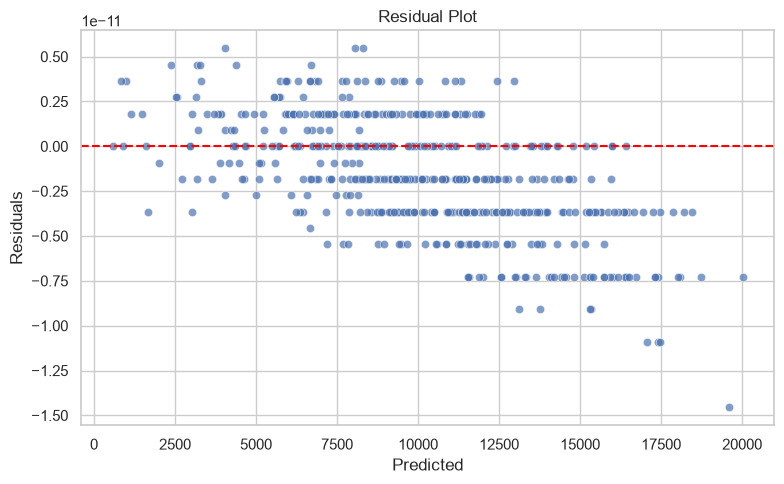

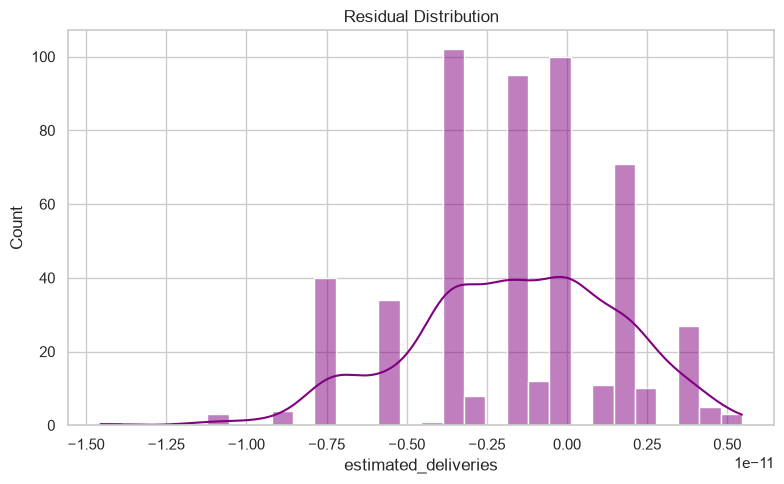

In [55]:
# 14. RESIDUAL ANALYSIS
best_preds = best_model.predict(X_test)
residuals  = y_test - best_preds

residual_df = pd.DataFrame({
    "actual":    y_test.values,
    "predicted": best_preds,
    "residual":  residuals
})
residual_df.to_csv(os.path.join(OUTPUT_DIR, "residuals.csv"), index=False)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_preds, y=residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted"); plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residual_plot.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30, color="purple")
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residual_distribution.png"), dpi=200)
plt.show()


## 15 & 16.  Save Best Model & Test Predictions

We persist:
- **Best model pipeline** as a `.pkl` file using `joblib` (includes both preprocessor and model — ready to deploy)
- **Test predictions** as a CSV for further analysis or reporting

Both are saved to the `output/` directory.

In [56]:
# 15. SAVE BEST MODEL
model_path = os.path.join(OUTPUT_DIR, f"best_model_{best_model_name}.pkl")
joblib.dump(best_model, model_path)
print("Saved best model to:", model_path)


Saved best model to: outputs\best_model_LinearRegression.pkl


In [57]:
# 16. SAVE TEST PREDICTIONS
test_predictions_df = pd.DataFrame({
    "actual":    y_test.values,
    "predicted": best_preds
})
test_predictions_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)
print("Saved test predictions.")


Saved test predictions.


## 17.  Time Series Forecasting with SARIMAX

Beyond regression, we model the **delivery time series** directly using **SARIMAX** (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors).

### Why SARIMAX?
- Captures **trend** (integrated `d` terms) and **autocorrelation** (AR/MA terms)
- Handles **seasonality** (quarterly cycles in EV delivery patterns)
- We do **grid search over ARIMA orders** and select the lowest AIC model

### Evaluation
We compare SARIMAX against a **naïve baseline** (always predict last known value).
The naive baseline sets the minimum bar — our SARIMAX should significantly beat it.

In [61]:
print("date_col:", date_col)
print("target_col:", target_col)
print("df[date_col] unique values:", df[date_col].dropna().unique()[:15].tolist())
print("df[date_col] dtype:", df[date_col].dtype)
print("df.columns:", df.columns.tolist())

date_col: year
target_col: estimated_deliveries
df[date_col] unique values: [Timestamp('2023-01-01 00:00:00'), Timestamp('2015-01-01 00:00:00'), Timestamp('2019-01-01 00:00:00'), Timestamp('2021-01-01 00:00:00'), Timestamp('2016-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2022-01-01 00:00:00'), Timestamp('2025-01-01 00:00:00'), Timestamp('2017-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'), Timestamp('2018-01-01 00:00:00')]
df[date_col] dtype: datetime64[us]
df.columns: ['year', 'month', 'region', 'model', 'estimated_deliveries', 'production_units', 'avg_price_usd', 'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'source_type', 'charging_stations']


TIME SERIES FORECASTING
Years         : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Observations  : 11
Date range    : 2015 → 2025
Date sanity check: PASSED


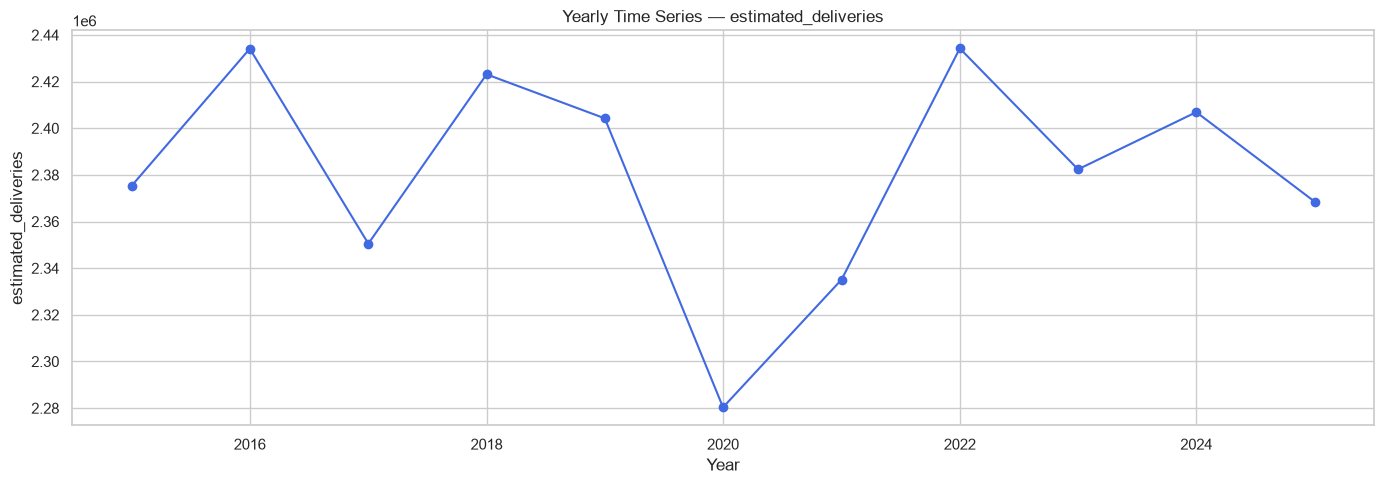


Train: 8 pts (2015 → 2022)
Test : 3 pts  (2023 → 2025)

Naive baseline  RMSE=50854.22  MAE=48308.00

Searching best SARIMAX model...

Best model: order=(2, 1, 0)  seasonal=(0, 0, 0, 0)  AIC=129.16
Test RMSE=74105.69  MAE=71563.98  R²=-20.7501


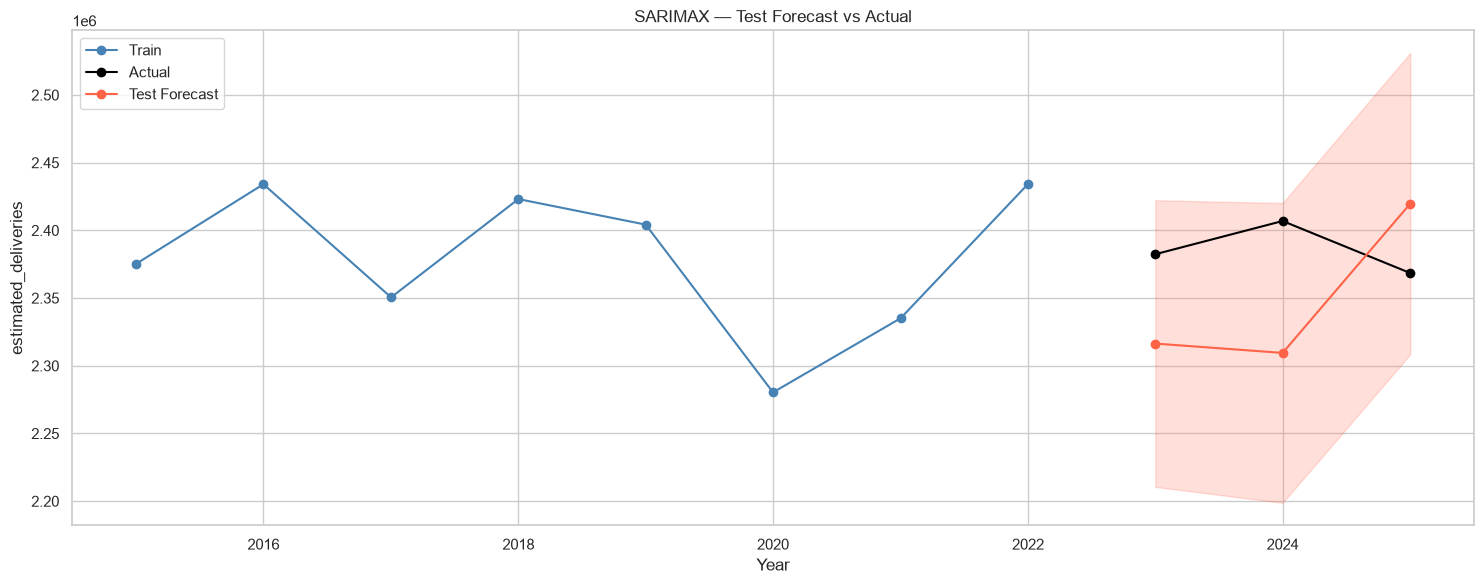


Future 5-year forecast (after 2025):
 Year     Forecast
 2026 2.375867e+06
 2027 2.391779e+06
 2028 2.379684e+06
 2029 2.377799e+06
 2030 2.385002e+06


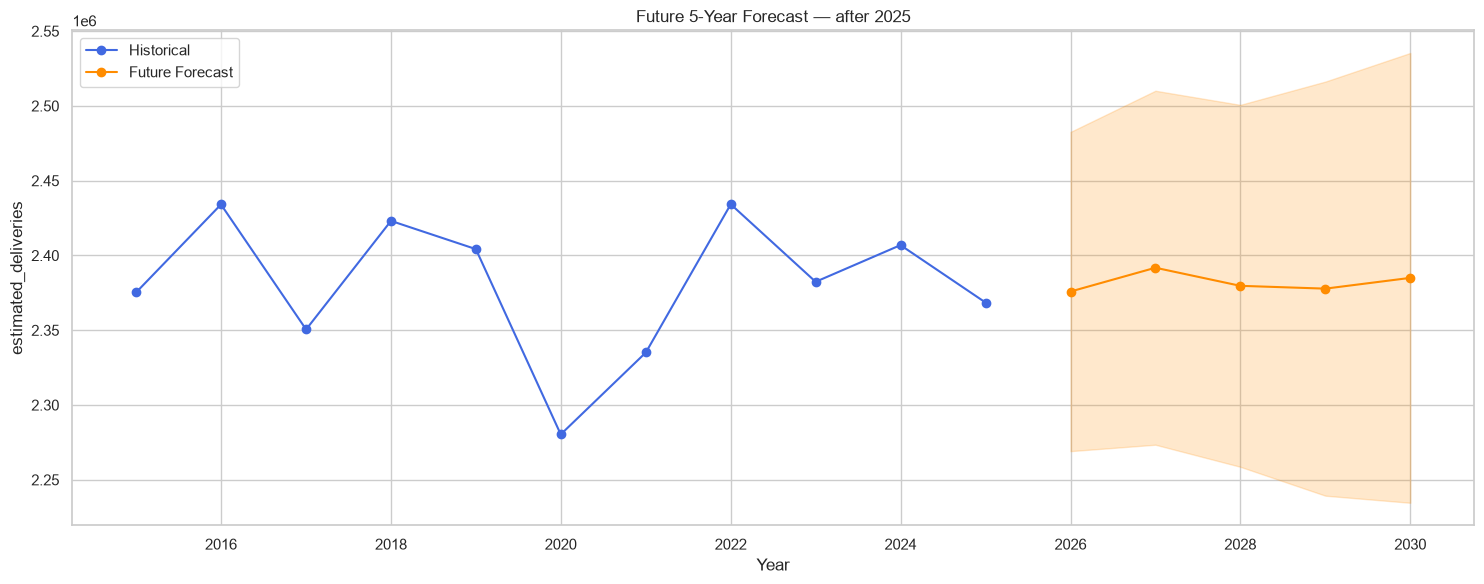

In [62]:
# 17. TIME SERIES FORECASTING WITH SARIMAX
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("TIME SERIES FORECASTING")
print("=" * 70)

# ── Step 1: Build yearly series ─────────────────────────────────────────────
# date_col ("year") is already datetime64 with values 2015-01-01 .. 2025-01-01
# Just extract the year integer and aggregate target by it.

temp = pd.DataFrame({
    "year":   pd.to_datetime(df[date_col], errors="coerce").dt.year,
    "target": pd.to_numeric(df[target_col], errors="coerce")
}).dropna()

temp = temp[temp["year"].between(1990, 2100)]

yearly = temp.groupby("year")["target"].sum().sort_index()

# Build a safe DatetimeIndex from year integers
yearly.index = pd.to_datetime(
    yearly.index.astype(int).astype(str), format="%Y"
)

ts_series = yearly.dropna()

print(f"Years         : {[i.year for i in ts_series.index]}")
print(f"Observations  : {len(ts_series)}")
print(f"Date range    : {ts_series.index.min().year} → {ts_series.index.max().year}")

freq         = "YE"
freq_label   = "Yearly"
future_steps = 5

# ── Step 2: Sanity check ────────────────────────────────────────────────────
assert ts_series.index.min().year >= 1990, f"Bad start year: {ts_series.index.min().year}"
assert ts_series.index.max().year <= 2030, f"Bad end year: {ts_series.index.max().year}"
print("Date sanity check: PASSED")

# ── Step 3: Plot historical series ──────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(ts_series.index, ts_series.values, marker="o", color="royalblue")
plt.title(f"Yearly Time Series — {target_col}")
plt.xlabel("Year"); plt.ylabel(target_col)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "time_series_original.png"), dpi=300)
plt.show(); plt.close()

# ── Step 4: SARIMAX ─────────────────────────────────────────────────────────
min_obs = 6
if len(ts_series) < min_obs:
    print(f"Only {len(ts_series)} observations — need at least {min_obs}.")
else:
    try:
        from statsmodels.tsa.statespace.sarimax import SARIMAX
    except ImportError:
        raise ImportError("statsmodels is not installed. Run: pip install statsmodels")

    split_idx = max(int(len(ts_series) * 0.80), len(ts_series) - 3)
    train_ts  = ts_series.iloc[:split_idx]
    test_ts   = ts_series.iloc[split_idx:]

    print(f"\nTrain: {len(train_ts)} pts ({train_ts.index.min().year} → {train_ts.index.max().year})")
    print(f"Test : {len(test_ts)} pts  ({test_ts.index.min().year} → {test_ts.index.max().year})")

    naive_pred = np.repeat(train_ts.iloc[-1], len(test_ts))
    print(f"\nNaive baseline  RMSE={np.sqrt(mean_squared_error(test_ts, naive_pred)):.2f}  "
          f"MAE={mean_absolute_error(test_ts, naive_pred):.2f}")

    orders          = [(1,1,0),(0,1,1),(1,1,1),(2,1,0)]
    seasonal_orders = [(0,0,0,0)]

    print("\nSearching best SARIMAX model...")
    best_aic, best_fit, best_order, best_seasonal = np.inf, None, None, None

    for order in orders:
        for seasonal in seasonal_orders:
            try:
                fit = SARIMAX(
                    train_ts, order=order, seasonal_order=seasonal,
                    enforce_stationarity=False, enforce_invertibility=False
                ).fit(disp=False)
                if np.isfinite(fit.aic) and fit.aic < best_aic:
                    best_aic, best_fit = fit.aic, fit
                    best_order, best_seasonal = order, seasonal
            except Exception:
                continue

    if best_fit is None:
        print("No valid SARIMAX model found.")
    else:
        pred     = best_fit.get_forecast(steps=len(test_ts)).predicted_mean
        conf_int = best_fit.get_forecast(steps=len(test_ts)).conf_int()

        ts_rmse = np.sqrt(mean_squared_error(test_ts, pred))
        ts_mae  = mean_absolute_error(test_ts, pred)
        ts_r2   = r2_score(test_ts, pred)

        print(f"\nBest model: order={best_order}  seasonal={best_seasonal}  AIC={best_aic:.2f}")
        print(f"Test RMSE={ts_rmse:.2f}  MAE={ts_mae:.2f}  R²={ts_r2:.4f}")

        pd.DataFrame({
            "Year":     [i.year for i in test_ts.index],
            "Actual":   test_ts.values,
            "Forecast": pred.values
        }).to_csv(os.path.join(OUTPUT_DIR, "time_series_forecast.csv"), index=False)

        plt.figure(figsize=(15, 6))
        plt.plot(train_ts.index, train_ts.values, label="Train",         color="steelblue", marker="o")
        plt.plot(test_ts.index,  test_ts.values,  label="Actual",        color="black",     marker="o")
        plt.plot(pred.index,     pred.values,      label="Test Forecast", color="tomato",    marker="o")
        plt.fill_between(conf_int.index,
                         conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2, color="tomato")
        plt.title("SARIMAX — Test Forecast vs Actual")
        plt.xlabel("Year"); plt.ylabel(target_col); plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "sarimax_forecast.png"), dpi=300)
        plt.show(); plt.close()

        # ── Refit on ALL data → forecast future ────────────────────────────
        final_fit = SARIMAX(
            ts_series, order=best_order, seasonal_order=best_seasonal,
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False)

        future_fc   = final_fit.get_forecast(steps=future_steps)
        future_pred = future_fc.predicted_mean
        future_ci   = future_fc.conf_int()

        last_year  = ts_series.index.max().year
        future_years = list(range(last_year + 1, last_year + future_steps + 1))

        future_df = pd.DataFrame({
            "Year":     future_years,
            "Forecast": future_pred.values
        })
        future_df.to_csv(os.path.join(OUTPUT_DIR, "future_forecast.csv"), index=False)

        print(f"\nFuture {future_steps}-year forecast (after {last_year}):")
        print(future_df.to_string(index=False))

        future_plot_idx = pd.to_datetime(
            [str(y) for y in future_years], format="%Y"
        )

        plt.figure(figsize=(15, 6))
        plt.plot(ts_series.index,   ts_series.values,   label="Historical",     color="royalblue",  marker="o")
        plt.plot(future_plot_idx,   future_pred.values, label="Future Forecast", color="darkorange", marker="o")
        plt.fill_between(future_plot_idx,
                         future_ci.iloc[:,0].values, future_ci.iloc[:,1].values,
                         alpha=0.2, color="darkorange")
        plt.title(f"Future {future_steps}-Year Forecast — after {last_year}")
        plt.xlabel("Year"); plt.ylabel(target_col); plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "future_forecast.png"), dpi=300)
        plt.show(); plt.close()

        forecast_results = future_df   # for summary cell

## 18.  Final Summary Report

This section consolidates all pipeline results into a final summary table for easy reference.

In [ ]:
# 18. FINAL SUMMARY
print("=" * 50)
print("FINAL REPORT")
print("=" * 50)
print("Best ML model  :", best_model_name)
print("Outputs saved in:", OUTPUT_DIR)
print("Files produced  :")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print("  •", f)

if "forecast_results" in globals() and forecast_results is not None:
    print("\nFuture forecast summary:")
    print(forecast_results.to_string(index=False))
